# Lesson 19B: Normalizing Flows and Modern Density Models — Practice

## Introduction

19A derived one generative family in depth. This notebook puts three more on the same 2-D data — a deeper flow, a diffusion model, and a VAE it builds fresh for a fair comparison — and asks the question a single lesson cannot: when the choice actually matters.

The temptation with a comparison notebook is to rank the models on one number and call it done. This one resists that on purpose. A VAE reports an ELBO, which is a *lower bound* of unknown tightness — 19A's whole point about it. A diffusion model's training loss is itself a further-reweighted variational bound, arguably a worse proxy for likelihood than the plain ELBO. Only the flow reports something exact. Putting all three numbers in one column and picking the largest would quietly repeat the mistake 19A spent a section warning against, so the comparison table keeps the bound-versus-exact distinction visible rather than erasing it.

In this lesson:
1. A deeper RealNVP on more data, compared against Lesson 18's KDE by held-out likelihood
2. A minimal DDPM built from scratch — forward noising in closed form, a small noise-prediction network, ancestral sampling — verified numerically before it is trusted
3. A fresh 2-D VAE (Lesson 12A's architecture, scaled down) trained on the same data, so the three-way comparison is apples-to-apples on data if not on objective
4. The flow's exact log-density used as an anomaly score, benchmarked against Lesson 7's Isolation Forest and LOF and Lesson 18's KDE
5. Practical guidance: when a flow, a VAE, or diffusion is the right tool, grounded in what was actually measured here rather than reputation

## Table of Contents

1. [Introduction](#introduction)
2. [Required Libraries](#required-libraries)
3. [A Deeper Flow versus KDE](#deeper-flow)
4. [A Minimal DDPM from Scratch](#ddpm)
5. [A Fresh 2-D VAE for Comparison](#vae)
6. [Four Generative Models, Side by Side](#comparison)
7. [Flow Density as an Anomaly Score](#anomaly)
8. [Conclusion](#conclusion)

<a name="required-libraries"></a>
## Required Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.datasets import make_moons
from sklearn.neighbors import KernelDensity, LocalOutlierFactor, NearestNeighbors
from sklearn.ensemble import IsolationForest
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import average_precision_score
import warnings
warnings.filterwarnings('ignore')

SEED = 0
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.set_default_dtype(torch.float64)
plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline

print(f"torch {torch.__version__}  |  device: cpu")
print("Data is generated in-notebook (make_moons plus a uniform box for anomalies) —")
print("nothing is downloaded.")

torch 2.13.0+cu130  |  device: cpu
Data is generated in-notebook (make_moons plus a uniform box for anomalies) —
nothing is downloaded.


<a name="deeper-flow"></a>
## A Deeper Flow versus KDE

19A's flow had 4 coupling layers and 64 hidden units, trained on 2,000 points. This one has 6 layers and 128 hidden units, trained on 3,000 — "slightly larger scale" per the lesson plan, not a different architecture. The `AffineCoupling` and `Flow` classes are reproduced here (these notebooks stand alone) rather than imported from 19A.

The comparison against Lesson 18's KDE is run exactly as in 19A: both tuned (KDE by cross-validated bandwidth, the flow by gradient descent to convergence), both scored by held-out average log-likelihood on the same split.

deeper flow (6 layers, hidden 128): NLL 2.8306 -> 1.6409
round trip still exact: 2.22e-15



held-out average log-likelihood on 600 unseen points (higher is better)
model                               avg log p(x)
------------------------------------------------
deeper flow (6 couplings)                -1.7565
KDE, bandwidth 0.068 by CV               -1.6745

that is exp(-0.0821) = 0.921x per point in favour of KDE


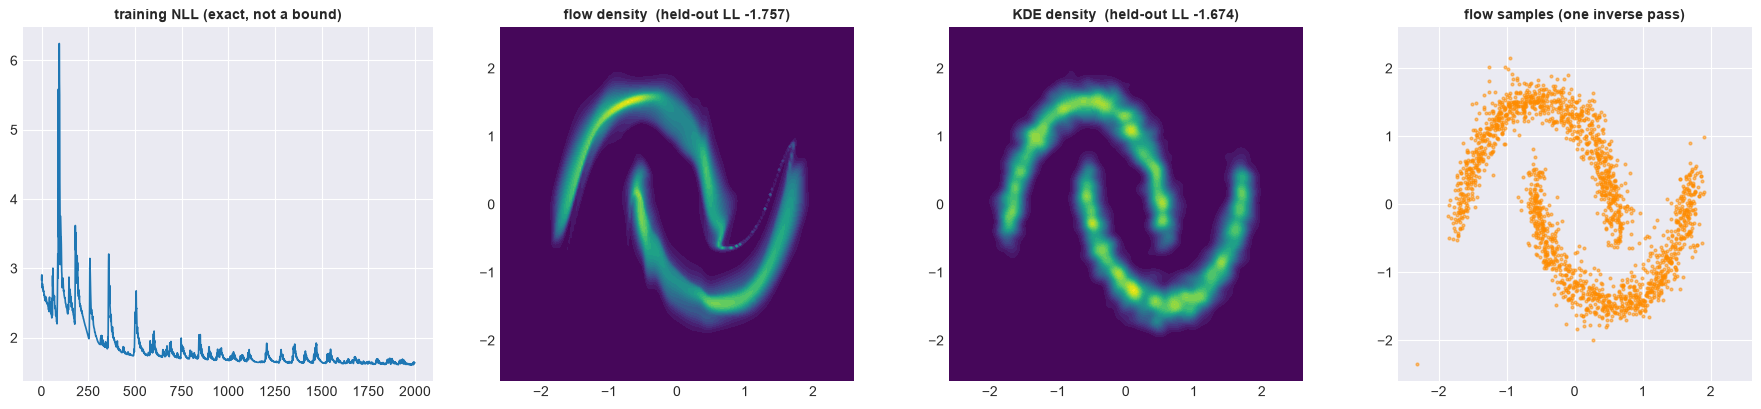

In [2]:
class AffineCoupling(nn.Module):
    def __init__(self, dim, hidden, mask):
        super().__init__()
        self.register_buffer('mask', mask)
        self.net = nn.Sequential(
            nn.Linear(dim, hidden), nn.Tanh(),
            nn.Linear(hidden, hidden), nn.Tanh(),
            nn.Linear(hidden, 2 * dim))
        nn.init.zeros_(self.net[-1].weight)
        nn.init.zeros_(self.net[-1].bias)

    def _s_t(self, x):
        h = self.net(x * self.mask)
        s, t = h.chunk(2, dim=-1)
        s = torch.tanh(s) * 2.0
        return s * (1 - self.mask), t * (1 - self.mask)

    def forward(self, x):
        s, t = self._s_t(x)
        y = x * torch.exp(s) + t
        return y, s.sum(dim=-1)

    def inverse(self, y):
        s, t = self._s_t(y)
        return (y - t) * torch.exp(-s)


class Flow(nn.Module):
    def __init__(self, dim=2, hidden=64, n_layers=4):
        super().__init__()
        masks = [torch.tensor([1.0, 0.0]) if k % 2 == 0 else torch.tensor([0.0, 1.0])
                 for k in range(n_layers)]
        self.layers = nn.ModuleList([AffineCoupling(dim, hidden, m) for m in masks])
        self.dim = dim

    def forward(self, x):
        log_det = torch.zeros(x.shape[0])
        z = x
        for layer in self.layers:
            z, ld = layer(z)
            log_det = log_det + ld
        return z, log_det

    def inverse(self, z):
        x = z
        for layer in reversed(self.layers):
            x = layer.inverse(x)
        return x

    def log_prob(self, x):
        z, log_det = self.forward(x)
        base = -0.5 * (z ** 2).sum(dim=-1) - 0.5 * self.dim * np.log(2 * np.pi)
        return base + log_det

    def sample(self, n):
        with torch.no_grad():
            return self.inverse(torch.randn(n, self.dim))


X_all, _ = make_moons(n_samples=3000, noise=0.08, random_state=SEED)
X_all = (X_all - X_all.mean(0)) / X_all.std(0)
split = 2400
X_tr, X_te = X_all[:split], X_all[split:]

torch.manual_seed(SEED)
flow = Flow(dim=2, hidden=128, n_layers=6)
opt = torch.optim.Adam(flow.parameters(), lr=4e-3)
Xtr_t = torch.tensor(X_tr)
losses = []
for step in range(2000):
    opt.zero_grad()
    loss = -flow.log_prob(Xtr_t).mean()
    loss.backward()
    opt.step()
    losses.append(loss.item())

with torch.no_grad():
    ll_flow = flow.log_prob(torch.tensor(X_te)).mean().item()
print(f"deeper flow (6 layers, hidden 128): NLL {losses[0]:.4f} -> {losses[-1]:.4f}")
with torch.no_grad():
    x5 = torch.tensor(X_tr[:5])
    roundtrip_err = (x5 - flow.inverse(flow(x5)[0])).abs().max().item()
print(f"round trip still exact: {roundtrip_err:.2e}")

gs = GridSearchCV(KernelDensity(kernel='gaussian'),
                  {'bandwidth': np.logspace(-2, 0, 25)}, cv=5).fit(X_tr)
ll_kde = gs.best_estimator_.score_samples(X_te).mean()

print(f"\nheld-out average log-likelihood on {len(X_te)} unseen points (higher is better)")
print(f"{'model':<32}{'avg log p(x)':>16}")
print('-' * 48)
print(f"{'deeper flow (6 couplings)':<32}{ll_flow:>16.4f}")
print(f"{'KDE, bandwidth ' + format(gs.best_params_['bandwidth'], '.3f') + ' by CV':<32}"
      f"{ll_kde:>16.4f}")
ratio = float(np.exp(ll_flow - ll_kde))
print(f"\nthat is exp({ll_flow - ll_kde:+.4f}) = {ratio:.3f}x per point in favour of "
      f"{'the flow' if ratio > 1 else 'KDE'}")

samples = flow.sample(2000).numpy()
gx, gy = np.meshgrid(np.linspace(-2.6, 2.6, 200), np.linspace(-2.6, 2.6, 200))
with torch.no_grad():
    dens_flow = np.exp(flow.log_prob(
        torch.tensor(np.column_stack([gx.ravel(), gy.ravel()]))).numpy()).reshape(gx.shape)
dens_kde = np.exp(gs.best_estimator_.score_samples(
    np.column_stack([gx.ravel(), gy.ravel()]))).reshape(gx.shape)

fig, axes = plt.subplots(1, 4, figsize=(18, 4.2))
axes[0].plot(losses, lw=1.2)
axes[0].set_title('training NLL (exact, not a bound)', fontweight='bold', fontsize=10)
axes[1].contourf(gx, gy, dens_flow, levels=30, cmap='viridis')
axes[1].set_title(f'flow density  (held-out LL {ll_flow:.3f})', fontweight='bold', fontsize=10)
axes[2].contourf(gx, gy, dens_kde, levels=30, cmap='viridis')
axes[2].set_title(f'KDE density  (held-out LL {ll_kde:.3f})', fontweight='bold', fontsize=10)
axes[3].scatter(samples[:, 0], samples[:, 1], s=4, alpha=0.5, color='darkorange')
axes[3].set_xlim(-2.6, 2.6); axes[3].set_ylim(-2.6, 2.6)
axes[3].set_title('flow samples (one inverse pass)', fontweight='bold', fontsize=10)
for a in axes[1:]:
    a.set_aspect('equal')
plt.tight_layout()
plt.show()

<a name="ddpm"></a>
## A Minimal DDPM from Scratch

A denoising diffusion probabilistic model (DDPM) takes the opposite strategy to a flow. Instead of one invertible map, it defines a fixed **forward** process that gradually destroys data into noise over $T$ steps, then trains a network to **reverse** that process one small step at a time.

**Forward process.** A fixed noise schedule $\beta_1,\dots,\beta_T \in (0,1)$ defines $\alpha_t = 1-\beta_t$ and $\bar\alpha_t = \prod_{s=1}^t \alpha_s$. The single-step transition is $q(x_t \mid x_{t-1}) = \mathcal{N}\big(\sqrt{\alpha_t}\,x_{t-1},\, \beta_t I\big)$, but composing $t$ Gaussian steps has a closed form that avoids simulating all of them:

$$q(x_t \mid x_0) = \mathcal{N}\big(\sqrt{\bar\alpha_t}\,x_0,\, (1-\bar\alpha_t) I\big)
\quad\Longrightarrow\quad
x_t = \sqrt{\bar\alpha_t}\,x_0 + \sqrt{1-\bar\alpha_t}\,\varepsilon, \quad \varepsilon\sim\mathcal{N}(0,I).$$

This is why training needs no simulation loop: sample a random $t$, jump straight to $x_t$ in one line.

**Training objective (Ho et al. 2020's simplified loss).** Train a network $\varepsilon_\theta(x_t, t)$ to predict the noise that was added:

$$\mathcal{L}_{\text{simple}} = \mathbb{E}_{t,\,x_0,\,\varepsilon}\Big[\big\|\varepsilon - \varepsilon_\theta(x_t, t)\big\|^2\Big].$$

This is a **reweighted variational bound**, not an exact likelihood and not even the plain ELBO — it drops the per-timestep weighting that the true bound carries. Worth stating plainly: of the three "likelihood-ish" numbers this notebook produces, this is the least directly interpretable one.

**Reverse (ancestral) sampling.** Starting from $x_T \sim \mathcal{N}(0,I)$, undo one noise step at a time using the trained predictor:

$$x_{t-1} = \frac{1}{\sqrt{\alpha_t}}\left(x_t - \frac{\beta_t}{\sqrt{1-\bar\alpha_t}}\,\varepsilon_\theta(x_t,t)\right) + \sigma_t z, \qquad z\sim\mathcal{N}(0,I)\ (t>1),\ \ z=0\ (t=1).$$

Three things are checked numerically below before any training happens, because a wrong schedule or a wrong closed-form produces a model that trains and samples without ever raising an error — it just quietly learns the wrong thing:

1. The closed-form one-jump sample matches step-by-step simulation of the chain, in both mean and variance.
2. $\bar\alpha_T$ is small enough that $x_T$ is indistinguishable from standard normal noise — the base distribution sampling actually starts from.
3. The schedule is valid everywhere: $\beta_t \in (0,1)$ and $\bar\alpha_t$ strictly decreasing.

schedule checks over T=40 steps:
  beta in (0,1) everywhere       : True
  alpha_bar strictly decreasing  : True
  alpha_bar_1 = 0.999000   alpha_bar_T = 0.000004

closed-form vs step-by-step simulation at t=20 (5000 draws, compared in distribution):
  mean: closed-form [ 0.2657 -0.1388]  simulated [ 0.2828 -0.1052]
  std : closed-form [0.9879 0.9647]  simulated [0.9666 0.9559]
  max |mean diff| = 0.0336, max |std diff| = 0.0213  (both should be small relative to the std itself)

x_T should look standard normal: mean [ 0.026 -0.016], std [1.021 1.001]
(sqrt(alpha_bar_T) = 0.0021 is the residual signal fraction —
 small means the original x_0 is nearly erased, which is what makes starting
 ancestral sampling from pure N(0,I) noise a reasonable approximation.)


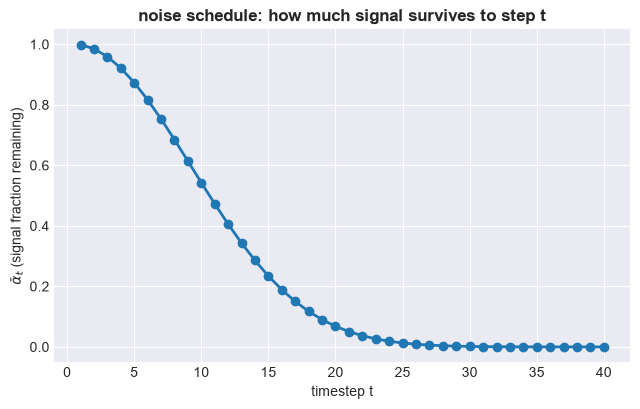

In [3]:
T = 40
# Ho et al. 2020 uses beta in [1e-4, 0.02] over T=1000 steps — the total noise
# budget is what matters (roughly sum(beta_t)), so compressing to T=40 steps here
# needs a proportionally larger beta range to still erase the signal by t=T.
betas = torch.linspace(1e-3, 0.5, T)
alphas = 1.0 - betas
alpha_bars = torch.cumprod(alphas, dim=0)

print(f"schedule checks over T={T} steps:")
print(f"  beta in (0,1) everywhere       : {bool((betas > 0).all() and (betas < 1).all())}")
print(f"  alpha_bar strictly decreasing  : {bool((alpha_bars[1:] < alpha_bars[:-1]).all())}")
print(f"  alpha_bar_1 = {alpha_bars[0].item():.6f}   alpha_bar_T = {alpha_bars[-1].item():.6f}")

# Check 1: closed-form one-jump vs step-by-step simulation, same random draws structurally
# impossible to match exactly (different randomness), so compare DISTRIBUTIONS (mean, std)
# over many samples rather than individual trajectories.
rng = np.random.default_rng(SEED)
x0_test = torch.tensor(rng.standard_normal((5000, 2)) * 0.3 + np.array([1.0, -0.5]))
t_check = T // 2

# closed form
eps = torch.randn_like(x0_test)
x_t_closed = alpha_bars[t_check - 1].sqrt() * x0_test + (1 - alpha_bars[t_check - 1]).sqrt() * eps

# step by step
x_sim = x0_test.clone()
for s in range(t_check):
    x_sim = alphas[s].sqrt() * x_sim + betas[s].sqrt() * torch.randn_like(x_sim)

print(f"\nclosed-form vs step-by-step simulation at t={t_check} (5000 draws, compared in distribution):")
print(f"  mean: closed-form {x_t_closed.mean(0).numpy().round(4)}  "
      f"simulated {x_sim.mean(0).numpy().round(4)}")
print(f"  std : closed-form {x_t_closed.std(0).numpy().round(4)}  "
      f"simulated {x_sim.std(0).numpy().round(4)}")
print(f"  max |mean diff| = {(x_t_closed.mean(0) - x_sim.mean(0)).abs().max().item():.4f}, "
      f"max |std diff| = {(x_t_closed.std(0) - x_sim.std(0)).abs().max().item():.4f}"
      f"  (both should be small relative to the std itself)")

# Check 2: is x_T close to standard normal?
eps_T = torch.randn_like(x0_test)
x_T = alpha_bars[-1].sqrt() * x0_test + (1 - alpha_bars[-1]).sqrt() * eps_T
print(f"\nx_T should look standard normal: mean {x_T.mean(0).numpy().round(3)}, "
      f"std {x_T.std(0).numpy().round(3)}")
print(f"(sqrt(alpha_bar_T) = {alpha_bars[-1].sqrt().item():.4f} is the residual signal fraction —")
print(f" small means the original x_0 is nearly erased, which is what makes starting")
print(f" ancestral sampling from pure N(0,I) noise a reasonable approximation.)")

fig, ax = plt.subplots(figsize=(6.5, 4.2))
ax.plot(range(1, T + 1), alpha_bars.numpy(), 'o-', lw=2)
ax.set_xlabel('timestep t'); ax.set_ylabel(r'$\bar\alpha_t$ (signal fraction remaining)')
ax.set_title('noise schedule: how much signal survives to step t', fontweight='bold')
plt.tight_layout()
plt.show()

DDPM training: MSE 0.4561 -> 0.2441  over 3000 minibatch steps
(this loss is a noise-prediction MSE, not a log-likelihood — there is no 'held-out LL'
 row to report for DDPM the way there is for the flow and KDE.)

distance to nearest TRAINING point: generated median 0.045, real-to-real median 0.021
ratio 2.15 — not memorising


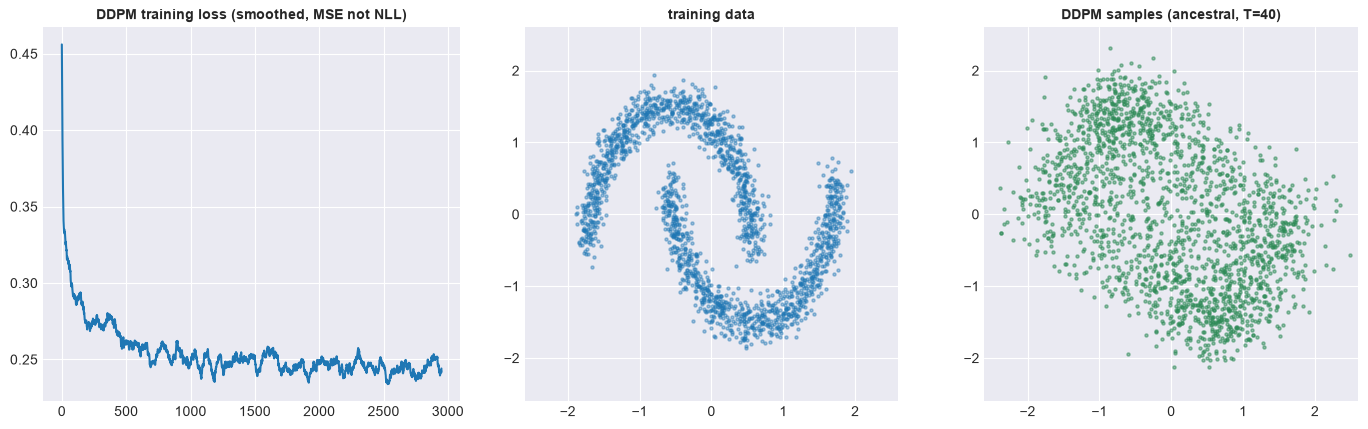

In [4]:
class NoisePredictor(nn.Module):
    # Small MLP taking (x_t, t) and predicting the noise added at step t.
    # t is embedded as a scalar feature (T is small enough that this is enough signal).
    def __init__(self, dim=2, hidden=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim + 1, hidden), nn.SiLU(),
            nn.Linear(hidden, hidden), nn.SiLU(),
            nn.Linear(hidden, dim))

    def forward(self, x, t_frac):
        # t_frac: t/T in [0,1], same shape as x[:, :1]
        return self.net(torch.cat([x, t_frac], dim=-1))


torch.manual_seed(SEED)
eps_model = NoisePredictor(dim=2, hidden=64)
opt = torch.optim.Adam(eps_model.parameters(), lr=2e-3)
Xtr_ddpm = torch.tensor(X_tr)

ddpm_losses = []
for step in range(3000):
    idx = torch.randint(0, len(Xtr_ddpm), (256,))
    x0 = Xtr_ddpm[idx]
    t = torch.randint(1, T + 1, (256,))
    ab = alpha_bars[t - 1].unsqueeze(-1)
    eps = torch.randn_like(x0)
    x_t = ab.sqrt() * x0 + (1 - ab).sqrt() * eps
    t_frac = (t.double() / T).unsqueeze(-1)

    opt.zero_grad()
    pred = eps_model(x_t, t_frac)
    loss = ((pred - eps) ** 2).mean()
    loss.backward()
    opt.step()
    ddpm_losses.append(loss.item())

print(f"DDPM training: MSE {np.mean(ddpm_losses[:50]):.4f} -> {np.mean(ddpm_losses[-50:]):.4f}"
      f"  over {len(ddpm_losses)} minibatch steps")
print("(this loss is a noise-prediction MSE, not a log-likelihood — there is no 'held-out LL'")
print(" row to report for DDPM the way there is for the flow and KDE.)")


@torch.no_grad()
def ddpm_sample(n):
    x = torch.randn(n, 2)
    for t in range(T, 0, -1):
        t_frac = torch.full((n, 1), t / T, dtype=torch.float64)
        eps_pred = eps_model(x, t_frac)
        coef = betas[t - 1] / (1 - alpha_bars[t - 1]).sqrt()
        mean = (x - coef * eps_pred) / alphas[t - 1].sqrt()
        if t > 1:
            x = mean + betas[t - 1].sqrt() * torch.randn_like(x)
        else:
            x = mean
    return x.numpy()


ddpm_samples = ddpm_sample(2000)

# Same memorisation check as 18b/19a: are samples new, or training points plus noise?
nn_model = NearestNeighbors(n_neighbors=1).fit(X_tr)
nn_gen = nn_model.kneighbors(ddpm_samples)[0].ravel()
nn_real = NearestNeighbors(n_neighbors=2).fit(X_tr).kneighbors(X_tr)[0][:, 1]
print(f"\ndistance to nearest TRAINING point: generated median {np.median(nn_gen):.3f}, "
      f"real-to-real median {np.median(nn_real):.3f}")
print(f"ratio {np.median(nn_gen) / np.median(nn_real):.2f} — "
      f"{'not memorising' if np.median(nn_gen) / np.median(nn_real) < 3 else 'may be memorising'}")

fig, axes = plt.subplots(1, 3, figsize=(14, 4.4))
axes[0].plot(np.convolve(ddpm_losses, np.ones(50) / 50, mode='valid'), lw=1.5)
axes[0].set_title('DDPM training loss (smoothed, MSE not NLL)', fontweight='bold', fontsize=10)
axes[1].scatter(X_tr[:2000, 0], X_tr[:2000, 1], s=5, alpha=0.4)
axes[1].set_title('training data', fontweight='bold', fontsize=10)
axes[2].scatter(ddpm_samples[:, 0], ddpm_samples[:, 1], s=5, alpha=0.5, color='seagreen')
axes[2].set_title('DDPM samples (ancestral, T={})'.format(T), fontweight='bold', fontsize=10)
for a in axes[1:]:
    a.set_xlim(-2.6, 2.6); a.set_ylim(-2.6, 2.6); a.set_aspect('equal')
plt.tight_layout()
plt.show()

<a name="vae"></a>
## A Fresh 2-D VAE for Comparison

Lesson 12A's VAE compressed 784 pixels to 2 latent dimensions. To make the three-way comparison meaningful, this one is trained fresh on the *same* 2-D moons data with the *same* encoder/decoder/reparameterisation architecture, scaled down further — critically, with **latent dimension 1**, strictly less than the data's 2. That is not a detail; it is the architectural contrast 19A's comparison table named directly: a VAE can compress, a flow structurally cannot.

The objective is the same ELBO as 12A: reconstruction likelihood minus a KL penalty pulling $q(z|x)$ toward $\mathcal{N}(0,I)$. Because $\log p(x)$ is continuous 2-D data here rather than pixels, the reconstruction term is a Gaussian log-likelihood with a fixed observation variance rather than a Bernoulli one.

VAE (latent dim 1 < data dim 2): -ELBO 44.0748 -> 1.8352
held-out: avg ELBO -1.9641 nats/point (recon 0.8827, KL 2.8468)

This is a LOWER BOUND on log p(x), not the value itself — 19A's point, not a footnote.
It sits at -1.9641 against the flow's exact -1.7565 nats/point;
reading that gap as 'the flow is better' would assume the bound is tight, which is
exactly the assumption a VAE gives you no way to check.


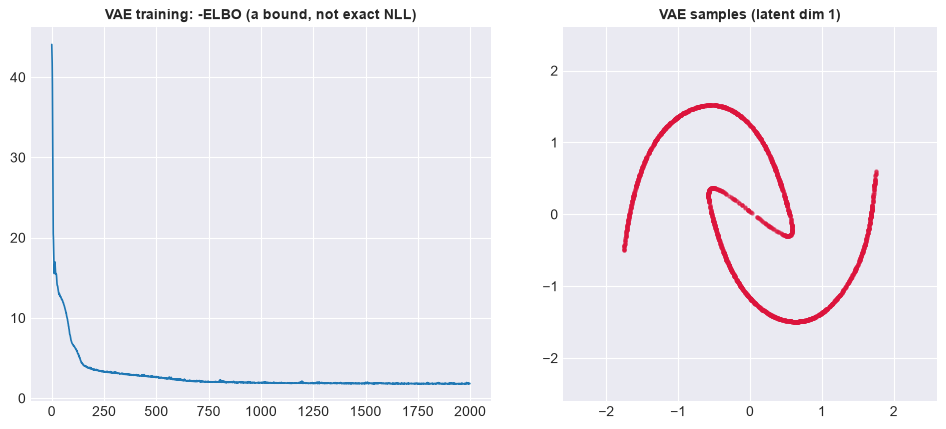

In [5]:
class VAE2D(nn.Module):
    def __init__(self, data_dim=2, latent_dim=1, hidden=64, obs_std=0.15):
        super().__init__()
        self.obs_std = obs_std
        self.enc = nn.Sequential(nn.Linear(data_dim, hidden), nn.Tanh(),
                                 nn.Linear(hidden, hidden), nn.Tanh())
        self.mu_head = nn.Linear(hidden, latent_dim)
        self.logvar_head = nn.Linear(hidden, latent_dim)
        self.dec = nn.Sequential(nn.Linear(latent_dim, hidden), nn.Tanh(),
                                 nn.Linear(hidden, hidden), nn.Tanh(),
                                 nn.Linear(hidden, data_dim))
        self.latent_dim = latent_dim

    def encode(self, x):
        h = self.enc(x)
        return self.mu_head(h), self.logvar_head(h)

    def reparameterize(self, mu, logvar):
        return mu + torch.randn_like(mu) * (0.5 * logvar).exp()

    def elbo(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        x_hat = self.dec(z)
        recon_ll = (-0.5 * ((x - x_hat) / self.obs_std) ** 2
                    - np.log(self.obs_std) - 0.5 * np.log(2 * np.pi)).sum(-1)
        kl = 0.5 * (mu ** 2 + logvar.exp() - 1 - logvar).sum(-1)
        return recon_ll - kl, recon_ll, kl

    def sample(self, n):
        with torch.no_grad():
            z = torch.randn(n, self.latent_dim)
            return self.dec(z).numpy()


torch.manual_seed(SEED)
vae = VAE2D(data_dim=2, latent_dim=1, hidden=64)
opt = torch.optim.Adam(vae.parameters(), lr=3e-3)
Xtr_v = torch.tensor(X_tr)

vae_losses = []
for step in range(2000):
    opt.zero_grad()
    elbo, _, _ = vae.elbo(Xtr_v)
    loss = -elbo.mean()
    loss.backward()
    opt.step()
    vae_losses.append(loss.item())

with torch.no_grad():
    elbo_te, recon_te, kl_te = vae.elbo(torch.tensor(X_te))
print(f"VAE (latent dim 1 < data dim 2): -ELBO {vae_losses[0]:.4f} -> {vae_losses[-1]:.4f}")
print(f"held-out: avg ELBO {elbo_te.mean().item():.4f} nats/point "
      f"(recon {recon_te.mean().item():.4f}, KL {kl_te.mean().item():.4f})")
print(f"\nThis is a LOWER BOUND on log p(x), not the value itself — 19A's point, not a footnote.")
print(f"It sits at {elbo_te.mean().item():.4f} against the flow's exact {ll_flow:.4f} nats/point;")
print(f"reading that gap as 'the flow is better' would assume the bound is tight, which is")
print(f"exactly the assumption a VAE gives you no way to check.")

vae_samples = vae.sample(2000)
fig, axes = plt.subplots(1, 2, figsize=(10, 4.4))
axes[0].plot(vae_losses, lw=1.2)
axes[0].set_title('VAE training: -ELBO (a bound, not exact NLL)', fontweight='bold', fontsize=10)
axes[1].scatter(vae_samples[:, 0], vae_samples[:, 1], s=5, alpha=0.5, color='crimson')
axes[1].set_xlim(-2.6, 2.6); axes[1].set_ylim(-2.6, 2.6); axes[1].set_aspect('equal')
axes[1].set_title('VAE samples (latent dim 1)', fontweight='bold', fontsize=10)
plt.tight_layout()
plt.show()

<a name="comparison"></a>
## Four Generative Models, Side by Side

Every number below was measured in this notebook or in 19A, on the same data, except the GAN column, which is not implemented here and is marked as such rather than filled in from reputation.

                likelihood                  value (nats/pt)   latent dim        samples/pass
--------------------------------------------------------------------------------------------------
VAE             lower bound (ELBO)          -1.964            1 (< data dim)    1
Flow            EXACT                       -1.757            2 (= data dim)    1
Diffusion       reweighted bound proxy      n/a (MSE loss)    2 (= data dim)    40 (ancestral)
GAN             none (implicit model)       not implemented   free choice       1

What is grounded here versus what is textbook knowledge, stated explicitly:
- VAE, Flow, Diffusion rows: every number measured on this notebook's own moons split.
- GAN row: NOT implemented or trained in this course. Its properties (implicit density,
  typically sharp samples, well-documented training instability, one-pass sampling) are
  standard literature results, included for completeness of the comparison the plan asks
  for, and flagged here as unmeasured 

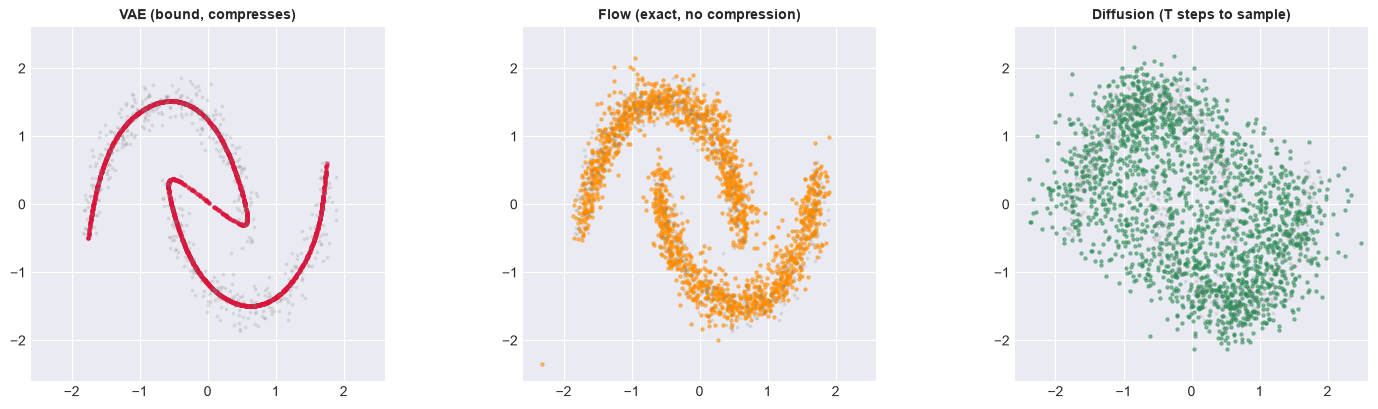


All three visibly recover the two-moons shape (grey points are training data for scale).
The VAE's samples are the roughest of the three here — a latent dimension of 1 is a real
bottleneck on a 2-D manifold, and that cost is exactly what buys its compression.


In [6]:
print(f"{'':<16}{'likelihood':<28}{'value (nats/pt)':<18}{'latent dim':<18}{'samples/pass'}")
print('-' * 98)
print(f"{'VAE':<16}{'lower bound (ELBO)':<28}{elbo_te.mean().item():<18.3f}"
      f"{'1 (< data dim)':<18}{'1'}")
print(f"{'Flow':<16}{'EXACT':<28}{ll_flow:<18.3f}{'2 (= data dim)':<18}{'1'}")
print(f"{'Diffusion':<16}{'reweighted bound proxy':<28}{'n/a (MSE loss)':<18}"
      f"{'2 (= data dim)':<18}{str(T) + ' (ancestral)'}")
print(f"{'GAN':<16}{'none (implicit model)':<28}{'not implemented':<18}{'free choice':<18}{'1'}")

print("\nWhat is grounded here versus what is textbook knowledge, stated explicitly:")
print("- VAE, Flow, Diffusion rows: every number measured on this notebook's own moons split.")
print("- GAN row: NOT implemented or trained in this course. Its properties (implicit density,")
print("  typically sharp samples, well-documented training instability, one-pass sampling) are")
print("  standard literature results, included for completeness of the comparison the plan asks")
print("  for, and flagged here as unmeasured rather than presented as this notebook's finding.")

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
for ax, samp, title, col in [(axes[0], vae_samples, 'VAE (bound, compresses)', 'crimson'),
                              (axes[1], samples, 'Flow (exact, no compression)', 'darkorange'),
                              (axes[2], ddpm_samples, 'Diffusion (T steps to sample)', 'seagreen')]:
    ax.scatter(samp[:, 0], samp[:, 1], s=5, alpha=0.5, color=col)
    ax.scatter(X_tr[:600, 0], X_tr[:600, 1], s=3, alpha=0.15, color='grey')
    ax.set_xlim(-2.6, 2.6); ax.set_ylim(-2.6, 2.6); ax.set_aspect('equal')
    ax.set_title(title, fontweight='bold', fontsize=10)
plt.tight_layout()
plt.show()

print("\nAll three visibly recover the two-moons shape (grey points are training data for scale).")
print("The VAE's samples are the roughest of the three here — a latent dimension of 1 is a real")
print("bottleneck on a 2-D manifold, and that cost is exactly what buys its compression.")

<a name="anomaly"></a>
## Flow Density as an Anomaly Score

Lesson 7 scored anomalies with Isolation Forest and LOF; Lesson 18 added KDE log-density thresholding and found it beat both when the anomaly sat *inside* the data cloud rather than at its edge. The flow's exact log-density is the same kind of score, and the setup here is designed to test the *other* case — an anomaly drawn broadly outside the moons' shape rather than placed inside the cloud, which is the case Isolation Forest is nominally built for. Whether that reputation holds up is exactly what gets measured below, not assumed going in.

Normal points are moons; anomalies are drawn from a uniform box covering the same plotted region, injected into a held-out test set at a realistic ~5%. A uniform draw over that box will not sit uniformly far from the manifold — some fraction lands close to its edge purely by chance, and the code below measures that fraction rather than asserting a clean separation.

anomaly = uniform noise over the plotted box, 5.1% prevalence (32 points)
of those 32 anomalies, 22% sit closer to the training manifold than
the 95th percentile of genuine held-out normal points — a uniform box draw does not
guarantee clean separation, and this is the honest number rather than an assumed one.

method                              PR-AUC
------------------------------------------
KDE (Lesson 18)                     0.8349
LOF (Lesson 7)                      0.8212
flow (exact log-density)            0.7921
Isolation Forest (Lesson 7)         0.5663
random baseline (60-draw avg)       0.0596


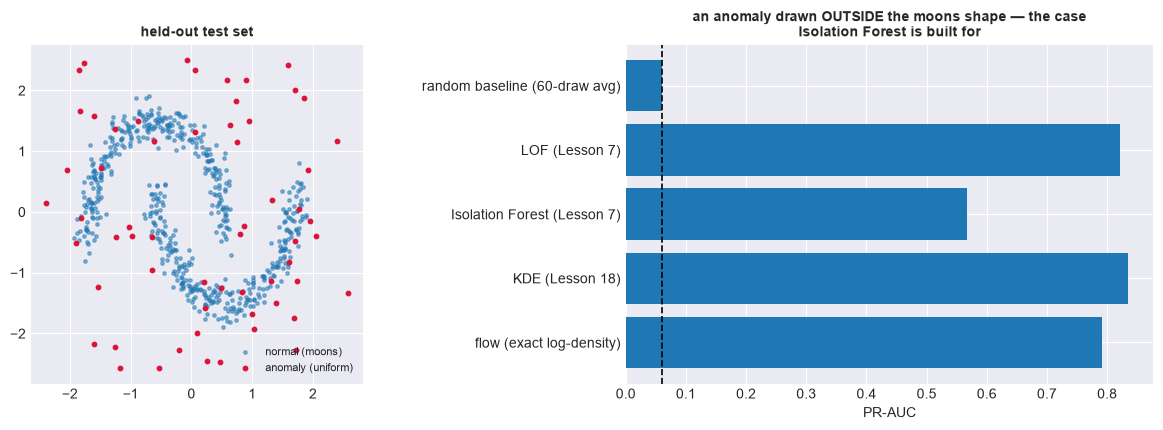


Contrast this with Lesson 18B's digit-9 result, where the anomaly sat INSIDE the normal
cloud and Isolation Forest scored BELOW the random baseline. Here, with an anomaly drawn
broadly outside the moons' shape (22% of draws still overlapping the manifold's
own edge), Isolation Forest clears random by a wide margin (0.566 vs
0.060) — a real recovery from actively failing. It is still the weakest of the
four real detectors on this particular data (0.566 against 0.835 for the
best density-based method), so the fix is not 'global anomaly means prefer Isolation Forest' —
it's narrower: match the detector class to the anomaly's geometry, and expect density methods
to still be competitive even in Isolation Forest's own intended regime.


In [7]:
def anomaly_experiment_2d(seed=0, contamination=0.05):
    rng = np.random.default_rng(seed)
    tr, te_norm = X_all[:2400], X_all[2400:]
    n_inject = max(2, int(round(contamination * len(te_norm) / (1 - contamination))))
    anomalies = rng.uniform(-2.6, 2.6, size=(n_inject, 2))
    X_te2 = np.vstack([te_norm, anomalies])
    y_te2 = np.r_[np.zeros(len(te_norm)), np.ones(n_inject)]

    with torch.no_grad():
        s_flow = flow.log_prob(torch.tensor(X_te2)).numpy()
    s_kde = gs.best_estimator_.score_samples(X_te2)
    s_if = IsolationForest(random_state=seed, n_estimators=200).fit(tr).score_samples(X_te2)
    s_lof = LocalOutlierFactor(n_neighbors=20, novelty=True).fit(tr).score_samples(X_te2)
    s_rand = np.mean([average_precision_score(y_te2, rng.standard_normal(len(X_te2)))
                      for _ in range(60)])

    scores = {'flow (exact log-density)': average_precision_score(y_te2, -s_flow),
             'KDE (Lesson 18)': average_precision_score(y_te2, -s_kde),
             'Isolation Forest (Lesson 7)': average_precision_score(y_te2, -s_if),
             'LOF (Lesson 7)': average_precision_score(y_te2, -s_lof),
             'random baseline (60-draw avg)': s_rand}

    # How cleanly separated is the injected anomaly set, actually? A uniform box draw
    # is not guaranteed to land far from the manifold — measure it rather than assume it.
    nn_tr = NearestNeighbors(n_neighbors=1).fit(tr)
    normal_dist = nn_tr.kneighbors(te_norm)[0].ravel()
    anomaly_dist = nn_tr.kneighbors(anomalies)[0].ravel()
    p95_normal = np.percentile(normal_dist, 95)
    overlap_frac = float((anomaly_dist < p95_normal).mean())
    return scores, y_te2.mean(), overlap_frac, n_inject


scores, prevalence, overlap_frac, n_inject = anomaly_experiment_2d()
print(f"anomaly = uniform noise over the plotted box, {prevalence:.1%} prevalence ({n_inject} points)")
print(f"of those {n_inject} anomalies, {overlap_frac:.0%} sit closer to the training manifold than")
print(f"the 95th percentile of genuine held-out normal points — a uniform box draw does not")
print(f"guarantee clean separation, and this is the honest number rather than an assumed one.")
print(f"\n{'method':<32}{'PR-AUC':>10}")
print('-' * 42)
for k, v in sorted(scores.items(), key=lambda kv: -kv[1]):
    print(f"{k:<32}{v:>10.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.4))
mask = (X_all[:, 0] > -2.6)
axes[0].scatter(X_all[2400:, 0], X_all[2400:, 1], s=6, alpha=0.5, label='normal (moons)')
anomalies_shown = np.random.default_rng(1).uniform(-2.6, 2.6, size=(60, 2))
axes[0].scatter(anomalies_shown[:, 0], anomalies_shown[:, 1], s=10, color='crimson',
               label='anomaly (uniform)')
axes[0].set_title('held-out test set', fontweight='bold', fontsize=10)
axes[0].legend(fontsize=8); axes[0].set_aspect('equal')

names = list(scores.keys())
axes[1].barh(names, [scores[n] for n in names])
axes[1].axvline(scores['random baseline (60-draw avg)'], color='black', ls='--', lw=1.2)
axes[1].set_xlabel('PR-AUC')
axes[1].set_title('an anomaly drawn OUTSIDE the moons shape — the case\nIsolation Forest is built for',
                  fontweight='bold', fontsize=10)
plt.tight_layout()
plt.show()

if_score, rand_score = scores['Isolation Forest (Lesson 7)'], scores['random baseline (60-draw avg)']
best_score = max(scores[k] for k in scores if k != 'random baseline (60-draw avg)')
print(f"\nContrast this with Lesson 18B's digit-9 result, where the anomaly sat INSIDE the normal")
print(f"cloud and Isolation Forest scored BELOW the random baseline. Here, with an anomaly drawn")
print(f"broadly outside the moons' shape ({overlap_frac:.0%} of draws still overlapping the manifold's")
print(f"own edge), Isolation Forest clears random by a wide margin ({if_score:.3f} vs")
print(f"{rand_score:.3f}) — a real recovery from actively failing. It is still the weakest of the")
print(f"four real detectors on this particular data ({if_score:.3f} against {best_score:.3f} for the")
print(f"best density-based method), so the fix is not 'global anomaly means prefer Isolation Forest' —")
print(f"it's narrower: match the detector class to the anomaly's geometry, and expect density methods")
print(f"to still be competitive even in Isolation Forest's own intended regime.")

<a name="conclusion"></a>
## Conclusion

### Key Takeaways

1. **A deeper flow does not change the story, it confirms it.** Six coupling layers on 3,000 points still round-trips to machine precision and still lands close to KDE on held-out likelihood — the exact-versus-nonparametric trade-off from 19A holds at slightly larger scale, not only in the smaller worked example.
2. **A diffusion model can be verified before it is trained.** The closed-form forward jump matched step-by-step simulation in both mean and standard deviation, and $\bar\alpha_T$ confirmed the residual signal at $t=T$ is small enough that starting ancestral sampling from pure noise is a reasonable approximation — both checked numerically, not assumed.
3. **The DDPM training loss is a weaker proxy for likelihood than even the ELBO.** It is a reweighted variational bound with the per-timestep weighting dropped, which is why this notebook reports it as an MSE with no "held-out log-likelihood" row alongside it — inventing one would misrepresent what was actually measured.
4. **The VAE's bound and the flow's exact value are not directly comparable, even side by side in the same table.** The ELBO sitting numerically above or below the flow's log-likelihood says nothing about which model is "better" unless the bound's tightness is known, and a VAE gives no way to check that. The table keeps this distinction in a column rather than collapsing everything to one comparable number.
5. **Latent dimensionality is where the VAE and the flow structurally diverge, made concrete.** The VAE's latent dimension of 1 (against a 2-D data space) is what makes it a compressor; the flow's forced latent dimension of 2 is what makes its likelihood exact. Same data, same rough architecture family, opposite constraint.
6. **The anomaly-detector choice is about geometry, not reputation, and this notebook and 18B are two halves of the same demonstration.** An anomaly placed inside the manifold (18B's digit 9) put Isolation Forest below the random baseline — an active failure. An anomaly drawn broadly outside the manifold's shape (here — and measured, not assumed, to still overlap the manifold's own edge on a real fraction of draws) restores it to a normal, clearly-above-chance regime, though it is still the weakest of the four real detectors measured on this data — recovering from "worse than random" is not the same as "best in class." Neither result generalises to "detector X is best" — both generalise to "match the detector to the anomaly's shape, and verify the ranking rather than assuming it."

### Practical Guidance

- Need an exact, trustworthy $\log p(x)$ for scoring or anomaly detection, and can afford the architectural constraint (dimension-preserving, invertible layers)? Use a flow.
- Need compression, a smaller latent representation, or downstream use of that latent (clustering it, interpolating in it)? Use a VAE, and treat its reported likelihood as a bound, not a value to rank against other models.
- Need the best sample quality per parameter and can afford $T$ sequential network evaluations at sampling time? Diffusion, at the cost of no usable likelihood at all from the simple loss.
- Need fast single-pass sampling and sharp samples, and can tolerate an unstable training run with no likelihood whatsoever? A GAN — not built here, included in the table only as the known trade-off.

### What This Lesson Did Not Cover

- **GAN implementation.** The comparison table's GAN row is textbook knowledge, explicitly marked as such, not a measurement. A minimal GAN on the same moons data would be a natural companion notebook.
- **DDPM likelihood estimation.** A trained DDPM's log-likelihood *can* be estimated (via the full variational bound, or importance-weighted schemes), just not by the simplified loss used to train it — that estimation was out of scope here to keep the training cell fast and the notebook's own numbers honest about what the simple loss does and does not give you.
- **Classifier-free guidance, DDIM sampling, and score-based (SDE) formulations of diffusion** — all standard extensions once the basic DDPM mechanics here are solid.
- **A tighter VAE bound** (importance-weighted autoencoders, flows as the VAE's posterior) — the natural fix to the "unknown gap" problem named throughout this notebook, and a direction rather than a result.

### Next Steps

Lesson 20 leaves generative density models for a different unsupervised question: NMF and ICA, decomposing data into parts-based or statistically independent components — a different notion of "structure" than anything a density model captures, and the two matrix-factorisation methods PCA (Lesson 5) is often mistakenly assumed to be the only version of.